# Restaurant Sales Analysis

This notebook performs a basic analysis of restaurant sales data using Python and Pandas.

The dataset used in this notebook is a small synthetic sample dataset created for learning GitHub, Python data analysis, and project structure.

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/Shehmeet/restaurant-sales-ai-analytics/refs/heads/main/data/restaurant_sales_sample.csv"

df = pd.read_csv(url)

df.head()

,order_id,date,time,item,category,quantity,unit_price,payment_method,order_type
0,1,2025-01-01,12:15,Chicken Burger,Main,2,14.5,EFTPOS,Dine-in
1,2,2025-01-01,12:45,Fries,Side,1,5.0,Cash,Takeaway
2,3,2025-01-01,13:10,Beef Burger,Main,1,15.5,EFTPOS,Dine-in
3,4,2025-01-02,18:20,Chicken Wrap,Main,2,12.0,Card,Takeaway
4,5,2025-01-02,19:05,Coke,Drink,3,3.5,EFTPOS,Dine-in


In [3]:
# Check number of rows and columns
df.shape

(10, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10 non-null     int64  
 1   date            10 non-null     object 
 2   time            10 non-null     object 
 3   item            10 non-null     object 
 4   category        10 non-null     object 
 5   quantity        10 non-null     int64  
 6   unit_price      10 non-null     float64
 7   payment_method  10 non-null     object 
 8   order_type      10 non-null     object 
dtypes: float64(1), int64(2), object(6)
memory usage: 852.0+ bytes


In [5]:
# Create a new column for total sales
df["total_sales"] = df["quantity"] * df["unit_price"]

# Show updated dataset
df.head()

,order_id,date,time,item,category,quantity,unit_price,payment_method,order_type,total_sales
0,1,2025-01-01,12:15,Chicken Burger,Main,2,14.5,EFTPOS,Dine-in,29.0
1,2,2025-01-01,12:45,Fries,Side,1,5.0,Cash,Takeaway,5.0
2,3,2025-01-01,13:10,Beef Burger,Main,1,15.5,EFTPOS,Dine-in,15.5
3,4,2025-01-02,18:20,Chicken Wrap,Main,2,12.0,Card,Takeaway,24.0
4,5,2025-01-02,19:05,Coke,Drink,3,3.5,EFTPOS,Dine-in,10.5


In [6]:
# Calculate total revenue
total_revenue = df["total_sales"].sum()

print("Total Revenue: $", total_revenue)

Total Revenue: $ 191.0


In [7]:
# Calculate sales by category
sales_by_category = df.groupby("category")["total_sales"].sum().sort_values(ascending=False)

print(sales_by_category)

category
Main     159.0
Side      21.5
Drink     10.5
Name: total_sales, dtype: float64


In [8]:
# Convert sales by category into a clean table
sales_by_category_table = sales_by_category.reset_index()

# Rename columns
sales_by_category_table.columns = ["Category", "Total Sales"]

sales_by_category_table

,Category,Total Sales
0,Main,159.0
1,Side,21.5
2,Drink,10.5


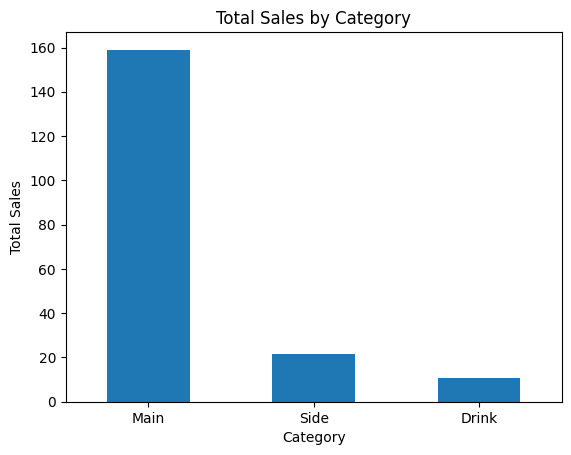

In [9]:
import matplotlib.pyplot as plt

# Create bar chart for sales by category
sales_by_category.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

## Sales by Category Insight

The bar chart shows that the **Main** category generated the highest total sales in the sample restaurant dataset.

This means main food items such as burgers, wraps, and kebabs contribute the most to restaurant revenue.

In [10]:
# Find top-selling items by quantity
top_items = df.groupby("item")["quantity"].sum().sort_values(ascending=False)

print(top_items)

item
Chicken Burger    5
Beef Burger       3
Coke              3
Fries             3
Chicken Wrap      2
Garlic Bread      1
Lamb Kebab        1
Name: quantity, dtype: int64


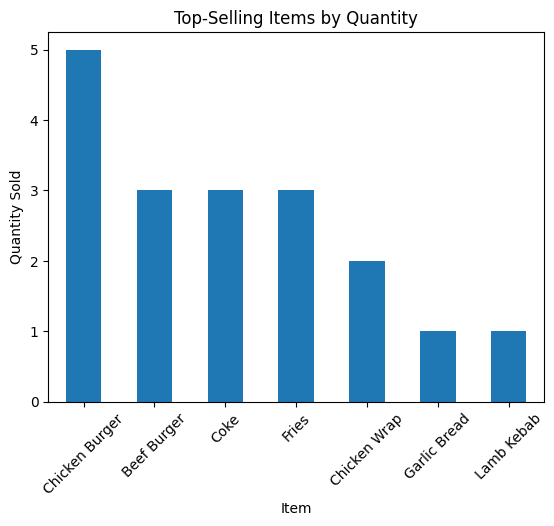

In [11]:

# Create bar chart for top-selling items
top_items.plot(kind="bar")

plt.title("Top-Selling Items by Quantity")
plt.xlabel("Item")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()


## Top-Selling Items Insight

The analysis shows that **Chicken Burger** is the top-selling item by quantity in the sample dataset.

This suggests that Chicken Burger is a popular menu item and could be promoted further using combo offers or meal deals.

In [12]:
# Analyse total sales by payment method
payment_sales = df.groupby("payment_method")["total_sales"].sum().sort_values(ascending=False)

print(payment_sales)

payment_method
EFTPOS    129.5
Card       40.5
Cash       21.0
Name: total_sales, dtype: float64


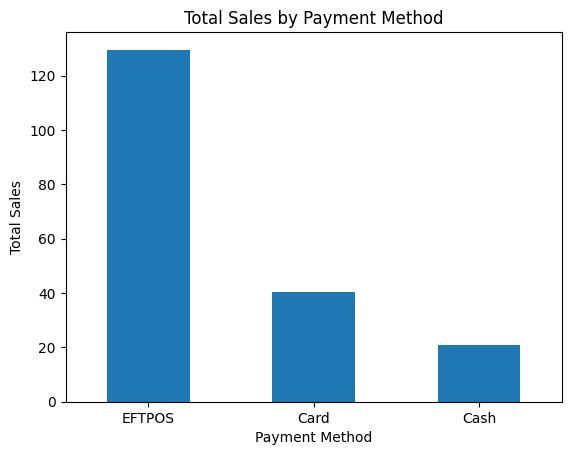

In [13]:
# Create bar chart for payment method sales
payment_sales.plot(kind="bar")

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

## Payment Method Insight

The analysis shows that **EFTPOS** generated the highest total sales in the sample dataset.

This suggests that most customers prefer electronic payments, so the restaurant should ensure that EFTPOS/card payment systems are always working smoothly.

In [14]:
# Analyse total sales by order type
order_type_sales = df.groupby("order_type")["total_sales"].sum().sort_values(ascending=False)

print(order_type_sales)

order_type
Dine-in     139.5
Takeaway     51.5
Name: total_sales, dtype: float64


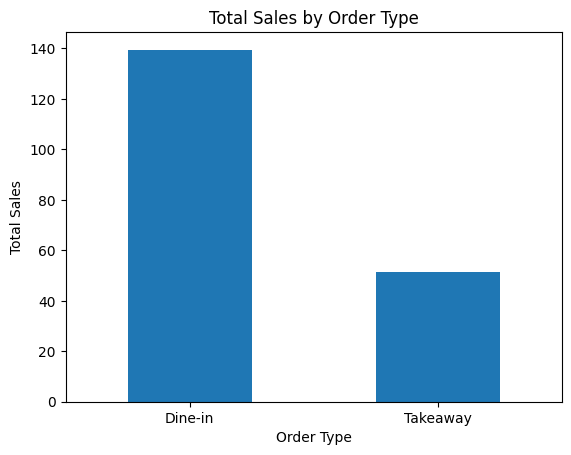

In [15]:
# Create bar chart for order type sales
order_type_sales.plot(kind="bar")

plt.title("Total Sales by Order Type")
plt.xlabel("Order Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()


## Order Type Insight

The analysis shows that **Dine-in** generated higher total sales than Takeaway in the sample dataset.

This suggests that dine-in customers may be purchasing more items or higher-value meals. The restaurant could increase revenue by promoting dine-in meal deals and improving the dine-in customer experience.

## Final Business Recommendations

Based on the sample restaurant sales analysis:

1. **Promote Main Items**  
   Main food items generated the highest revenue, so the restaurant should continue promoting burgers, wraps, and kebabs.

2. **Focus on Chicken Burger**  
   Chicken Burger was the top-selling item by quantity. It could be used in combo deals or special offers.

3. **Maintain Reliable EFTPOS/Card Payments**  
   EFTPOS generated the highest sales, showing that customers prefer electronic payments.

4. **Improve Dine-in Experience**  
   Dine-in orders generated higher total sales than takeaway, so improving dine-in service and meal deals may increase revenue.

## Conclusion

This project demonstrates basic data analysis using Python and Pandas. The notebook analyses restaurant sales data, creates useful business insights, and provides recommendations for improving restaurant performance.